# analysis.organism-range

In this notebook we will study the *organism range*, a property that could be seen as the analogue of organism *host-range* in hosts. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from daforfer import DaforferDB
import powerlaw
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

┌─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  name   │                                                        description                                                        │
│ varchar │                                                          varchar                                                          │
├─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1 │ Table S1: Library sites and context                                                                                       │
│ TableS2 │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3 │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4 │ Habitat-level diversity and number o

## Load data

In [2]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left')#.dropna(subset='taxid')
# bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)

# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left')#.dropna(subset='taxid')
# virus_hits['taxid'] = virus_hits['taxid'].astype(int)

## Organism range calculation

In [3]:

host_bacteria_range = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'bacteria_range'})

host_bacteria_range

,host_taxon,bacteria_range
0,Conyza bonariensis,43
1,Bromus sp,37
2,Convolvulus arvensis,37
3,Amaranthus sp,17
4,Diplotaxis erucoides,17
...,...,...
70,Lavandula latifolia,1
71,Lithodora fruticosa,1
72,Marrubium vulgare,1
73,Phlomis lychnitis,1


In [4]:
host_virus_range = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'virus_range'})
host_virus_range

,host_taxon,virus_range
0,Diplotaxis erucoides,41
1,Picris echioides,35
2,Convolvulus arvensis,32
3,Amaranthus sp,32
4,Rubia peregrina,32
...,...,...
101,Dittrichia viscosa,1
102,Borago officinalis,1
103,Aphyllanthes monspeliensis,1
104,Melilotus sp,1


In [5]:
organism_range = pd.merge(host_bacteria_range, host_virus_range, on='host_taxon', how='outer').fillna(0)
# WE will save this dataframe later
organism_range

,host_taxon,bacteria_range,virus_range
0,Allium sativum,0.0,4.0
1,Amaranthus sp,17.0,32.0
2,Anacyclus clavatus,7.0,14.0
3,Anchusa undulata,5.0,19.0
4,Andryala arenaria,5.0,3.0
...,...,...,...
108,Trifolium tomentosum,1.0,2.0
109,Verbascum sinuatum,8.0,10.0
110,Vicia sp,7.0,20.0
111,Xanthium strumarium,0.0,2.0


Below, we will visualize the organisms range using a histogram.

In [6]:
organism_range_melt = organism_range.melt(id_vars=['host_taxon'], value_vars=['bacteria_range', 'virus_range'])
organism_range_melt['variable'] = organism_range_melt['variable'].apply(lambda x: x.replace("_range", ""))
organism_range_melt = organism_range_melt.rename(columns={'variable':'kingdom', 'value':'range'})
organism_range_melt

,host_taxon,kingdom,range
0,Allium sativum,bacteria,0.0
1,Amaranthus sp,bacteria,17.0
2,Anacyclus clavatus,bacteria,7.0
3,Anchusa undulata,bacteria,5.0
4,Andryala arenaria,bacteria,5.0
...,...,...,...
221,Trifolium tomentosum,virus,2.0
222,Verbascum sinuatum,virus,10.0
223,Vicia sp,virus,20.0
224,Xanthium strumarium,virus,2.0


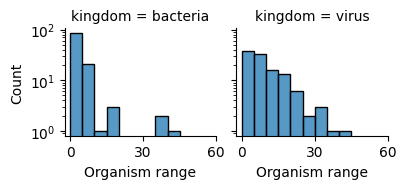

In [7]:

max_range = (organism_range_melt['range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=organism_range_melt, x='range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60])
g.set_xlabels("Organism range")
g.set_ylabels("Count")
g.savefig("figures/displot.organism-range.colbykingdom.svg")

## Regression analysis between bacteria and virus range

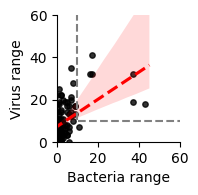

In [8]:
g = sns.lmplot(data=organism_range, x='bacteria_range', y='virus_range', height=2.0,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'}, truncate=False)
g.set_xlabels("Bacteria range")
g.set_ylabels("Virus range")
g.ax.set_xlim(0, 60)
g.ax.set_ylim(0, 60)
g.ax.set_xticks([0, 20, 40, 60])
g.ax.set_yticks([0, 20, 40, 60])
g.ax.axvline(10, ymin=0.17, ymax=1.0, color='gray', linestyle='--')
g.ax.axhline(10, xmin=0.17, xmax=1.0, color='gray', linestyle='--')
g.savefig("figures/linreg.bact-range.virus-range.svg")

In [9]:
test_1 = stats.linregress(organism_range['bacteria_range'], organism_range['virus_range'])

test_1_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Regression between bacteria and virus range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_1.pvalue}, # type: ignore
    {"key": "significative", "value": test_1.pvalue < 0.05}, # type: ignore
    {"key": "intercept", "value": test_1.intercept}, # type: ignore
    {"key": "slope", "value": test_1.slope}, # type: ignore
    {"key": "r-value", "value": test_1.rvalue}, # type: ignore
    {"key": "R2", "value": test_1.rvalue ** 2} # type: ignore

])

db.save_dataframe(test_1_results, "T_orgRangeCorr", "Regression between bacteria and virus range")
test_1_results



Saved T_orgRangeCorr to db.2025-11-17


,key,value
0,title,Regression between bacteria and virus range
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,7.185993
7,slope,0.644957
8,r-value,0.520995
9,R2,0.271436


## Computing total organism range

In [10]:
organism_range['total'] = organism_range['bacteria_range'] + organism_range['virus_range']
organism_range.sort_values(by='total', ascending=False)

,host_taxon,bacteria_range,virus_range,total
27,Convolvulus arvensis,37.0,32.0,69.0
28,Conyza bonariensis,43.0,18.0,61.0
40,Diplotaxis erucoides,17.0,41.0,58.0
21,Bromus sp,37.0,19.0,56.0
1,Amaranthus sp,17.0,32.0,49.0
...,...,...,...,...
13,Astragalus sesameus,1.0,0.0,1.0
43,Dittrichia viscosa,0.0,1.0,1.0
61,Lavandula latifolia,1.0,0.0,1.0
64,Lithodora fruticosa,1.0,0.0,1.0


## Cooccurrences at host level

Now, let's also include whether these organisms also include a higher number of cooccurrences. We will load first the cooccurrence network

In [11]:
cooccurrence_detection_pairs_by_library = db.conn.sql('SELECT * FROM D_coocPairDetections').df()
cooccurrence_detections_by_host = pd.merge(metadata, cooccurrence_detection_pairs_by_library, on='library').drop_duplicates(
    ['host_taxon', 'pair']
)[['host_taxon', 'pair']].value_counts('host_taxon').reset_index().rename(columns={'count': 'n_cooccurrences'})
cooccurrence_detections_by_host


,host_taxon,n_cooccurrences
0,Conyza bonariensis,38
1,Amaranthus sp,36
2,Diplotaxis erucoides,21
3,Datura stramonium,20
4,Carduus bourgeanus,19
5,Daucus sp,19
6,Convolvulus arvensis,19
7,Vicia sp,17
8,Rubia peregrina,12
9,Cynodon dactylon,9


In [12]:
organism_range = pd.merge(organism_range, cooccurrence_detections_by_host, on='host_taxon', how='left').fillna(0)

Now, we can make subnetworks out of the original network, and simply count the number of edges.

In [13]:
# organism_range = pd.merge(organism_range, host_organism_range_scientific_name[['host_taxon', 'n_cooccurrences']], on='host_taxon', how='outer').fillna(0)
organism_range['all_possible_cooccurrences'] = organism_range['bacteria_range'] * organism_range['virus_range']
organism_range = pd.merge(organism_range, metadata[['host_taxon', 'habitat']].drop_duplicates().groupby('host_taxon', as_index=False)['habitat'].apply(lambda x: ", ".join(list(x))), on='host_taxon')
db.save_dataframe(
    organism_range, table_name="D_organismRange", 
    description="Hosts bacteria and virus ranges"
)
si.save_dataframe(
    organism_range, table_name="Table10", 
    description="Hosts bacteria and virus ranges"
)
organism_range

Saved D_organismRange to db.2025-11-17
Saved Table10 to si.2025-11-17


,host_taxon,bacteria_range,virus_range,total,n_cooccurrences,all_possible_cooccurrences,habitat
0,Allium sativum,0.0,4.0,4.0,0.0,0.0,Edge
1,Amaranthus sp,17.0,32.0,49.0,36.0,544.0,"Edge, Crop"
2,Anacyclus clavatus,7.0,14.0,21.0,7.0,98.0,"Wasteland, Crop, Edge"
3,Anchusa undulata,5.0,19.0,24.0,1.0,95.0,"Wasteland, Edge"
4,Andryala arenaria,5.0,3.0,8.0,3.0,15.0,Oak
...,...,...,...,...,...,...,...
108,Trifolium tomentosum,1.0,2.0,3.0,0.0,2.0,Wasteland
109,Verbascum sinuatum,8.0,10.0,18.0,2.0,80.0,Wasteland
110,Vicia sp,7.0,20.0,27.0,17.0,140.0,"Wasteland, Edge"
111,Xanthium strumarium,0.0,2.0,2.0,0.0,0.0,Crop


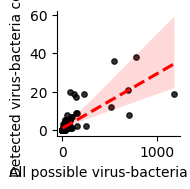

In [14]:
g = sns.lmplot(data=organism_range, x='all_possible_cooccurrences', y='n_cooccurrences', height=2.0,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("All possible virus-bacteria cooc.")
g.set_ylabels("Detected virus-bacteria cooc.")
g.savefig("figures/linreg.poscooc_cooc.svg")

In [15]:
test_2 = stats.linregress(organism_range['all_possible_cooccurrences'], organism_range['n_cooccurrences'])

test_2_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Possible cooccurrences versus detected cooccurrences"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_2.pvalue}, #type: ignore
    {"key": "significative", "value": test_2.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test_2.intercept}, #type: ignore
    {"key": "slope", "value": test_2.slope}, #type: ignore
    {"key": "r-value", "value": test_2.rvalue}, #type: ignore
    {"key": "R2", "value": test_2.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_2_results, table_name="T_hostCooc", 
    description="Correlation test between possible cooccurences and detected cooccurences at host level"
)
test_2_results


Saved T_hostCooc to db.2025-11-17


,key,value
0,title,Possible cooccurrences versus detected cooccur...
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,0.976848
7,slope,0.028343
8,r-value,0.751591
9,R2,0.564889


In [16]:
organism_range.query('all_possible_cooccurrences < 250').query('n_cooccurrences > 15')

,host_taxon,bacteria_range,virus_range,total,n_cooccurrences,all_possible_cooccurrences,habitat
22,Carduus bourgeanus,8.0,28.0,36.0,19.0,224.0,"Wasteland, Edge, Oak, Crop"
35,Datura stramonium,7.0,12.0,19.0,20.0,84.0,"Edge, Crop"
36,Daucus sp,9.0,13.0,22.0,19.0,117.0,Edge
110,Vicia sp,7.0,20.0,27.0,17.0,140.0,"Wasteland, Edge"


In [17]:
db.conn.close()
si.conn.close()